In [84]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from dadapy.metric_comparisons import MetricComparisons
from utilities import *
from imbalance_gain import compute_rank_matrix
from tqdm.auto import tqdm

plt.style.use(['science','notebook'])

In [86]:
def compute_info_imbalance(data_A, data_B, k=1, ngroups_array=[5,10,20,50,100,200,500,1000], metric="euclidean"):

    if data_A.shape[0] != data_B.shape[0]:
        raise ValueError("Number of points must be the same in the two representations!")
    N = data_A.shape[0]
    for ngroups in ngroups_array:
        assert N % ngroups == 0, f"N = {N} cannot be divided by ngroups = {ngroups}"
    rank_matrix_A = compute_rank_matrix(data_A, metric=metric)
    rank_matrix_B = compute_rank_matrix(data_B, metric=metric)

    # Find the nn indices in space A
    nns_A = nns_index_array(rank_matrix_A, k=k)

    # Find conditional ranks in space B
    for ngroups in ngroups_array:
        N_group = N // ngroups
        conditional_ranks_B = np.zeros((ngroups, N_group, k))

        for i_group in np.arange(ngroups):
            for i_point in np.arange(i_group*N_group, (i_group+1)*N_group):
                rank_B = rank_matrix_B[i_point][nns_A[i_point]]
                conditional_ranks_B[i_group,i_point%N_group] = rank_B
        conditional_ranks_B = conditional_ranks_B.reshape((ngroups, N_group*k))

        imbs_groups_A_to_B = 2/N * conditional_ranks_B.mean(axis=1)

        # The information imbalance A->B:
        imb_A_to_B = np.mean(imbs_groups_A_to_B)

        # The SE of the average among the groups:
        err_A_to_B = np.std(imbs_groups_A_to_B) / np.sqrt(ngroups)

        yield imb_A_to_B, err_A_to_B

In [168]:
# create test dataset and define parameters
N = 500
k = 1

cov = np.identity(2)
cov[-1, -1] = 0.01**2 # variance along z is much smaller!
mean = np.zeros(2)

In [169]:
# compute ground truth error through really independent samples
nsamples = 500
imbs_indep = np.zeros(nsamples)
for i in tqdm(range(nsamples)):
    X = np.random.multivariate_normal(mean = mean, cov = cov, size = (N))
    d = MetricComparisons(X, maxk=N-1, njobs=4)
    imbs_indep[i], _ = d.return_inf_imb_two_selected_coords(coords1=[0], coords2=[0,1], k=k)
err_ground_truth = imbs_indep.std()

  0%|          | 0/500 [00:00<?, ?it/s]

In [191]:
# estimate error with block method
ngroups_array=[5,10,20,50,100,250,500]
X = np.random.multivariate_normal(mean = mean, cov = cov, size = (N))

imbs_and_errors = [a for a in compute_info_imbalance(
    data_A = X[:,0].reshape((-1,1)),
    data_B = X, 
    k=k, ngroups_array=ngroups_array
)]
imbs_and_errors = np.array(imbs_and_errors)

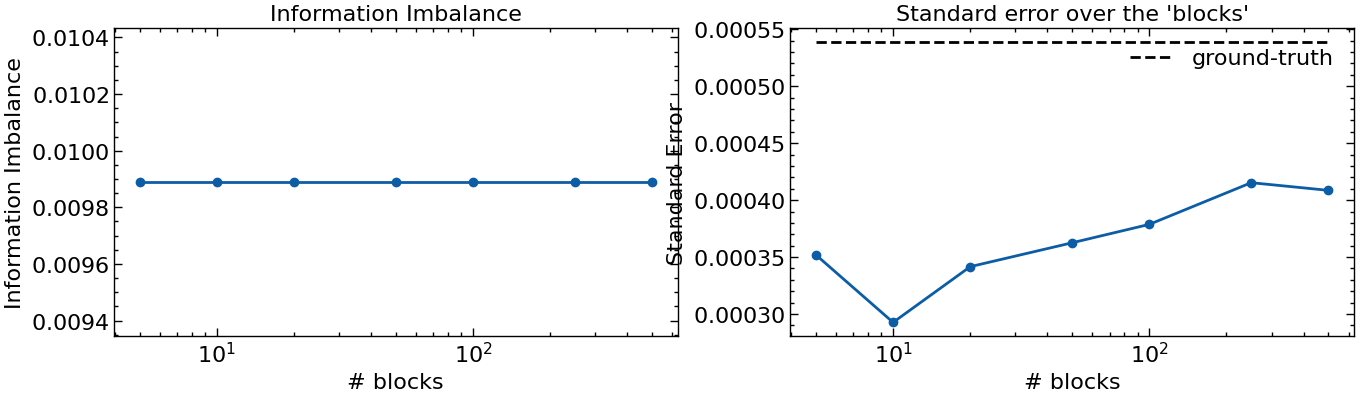

In [192]:
fig, ax = plt.subplots(1,2,figsize=(16,4))
ax[0].plot(ngroups_array, imbs_and_errors[:,0], 'o-')
ax[1].plot(ngroups_array, imbs_and_errors[:,1], 'o-')
ax[1].hlines(err_ground_truth, ngroups_array[0],ngroups_array[-1], linestyle='--', color="black", label="ground-truth")
ax[0].set(title="Information Imbalance", xlabel="# blocks", ylabel="Information Imbalance", xscale="log")
ax[1].set(title="Standard error over the 'blocks'", xlabel="# blocks", ylabel="Standard Error", xscale="log")
ax[1].legend()
plt.show()


### Study behavior vs k

In [ ]:
# compute ground truth error through really independent samples
nsamples = 500
imbs_indep = np.zeros(nsamples)
for i in tqdm(range(nsamples)):
    X = np.random.multivariate_normal(mean = mean, cov = cov, size = (N))
    d = MetricComparisons(X, maxk=N-1)
    imbs_indep[i], _ = d.return_inf_imb_two_selected_coords(coords1=[0], coords2=[0,1], k=k)
err_ground_truth = imbs_indep.std()